In [2]:
#import data manipulation libraries
import numpy as np
import pandas as pd

#import data visualziation libraries
import matplotlib.pyplot as plt
import seaborn as sns

#import logging
import logging
logging.basicConfig(filename='model.log',
                    level=logging.INFO,
                    filemode='w',
                      format='%(asctime)s:%(levelname)s:%(message)s',
                      force=True)

import warnings
warnings.filterwarnings('ignore')

In [3]:
#data import using pandas function
df=pd.read_excel('Real estate valuation data set.xlsx')
#shuffle the dataset
df.sample(frac=1)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
148,149,2013.500000,16.4,3780.5900,0,24.93293,121.51203,45.1
17,18,2012.750000,17.7,350.8515,1,24.97544,121.53119,37.4
111,112,2013.583333,33.3,196.6172,7,24.97701,121.54224,39.4
140,141,2013.250000,16.2,289.3248,5,24.98203,121.54348,51.4
296,297,2012.750000,12.5,1144.4360,4,24.99176,121.53456,34.1
...,...,...,...,...,...,...,...,...
173,174,2013.083333,41.3,401.8807,4,24.98326,121.54460,35.1
244,245,2013.083333,4.8,1559.8270,3,24.97213,121.51627,21.7
21,22,2013.416667,10.5,279.1726,7,24.97528,121.54541,51.6
125,126,2013.166667,1.1,193.5845,6,24.96571,121.54089,48.6


In [4]:
#separating numerical and categorical data
numerical_data=df.select_dtypes(exclude=object)
categorial_data=df.select_dtypes(include=object)

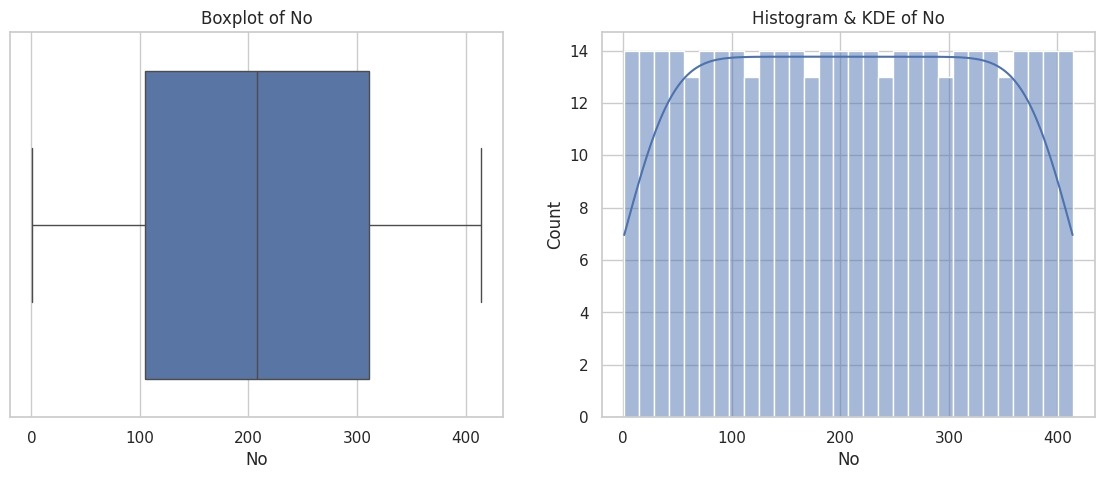

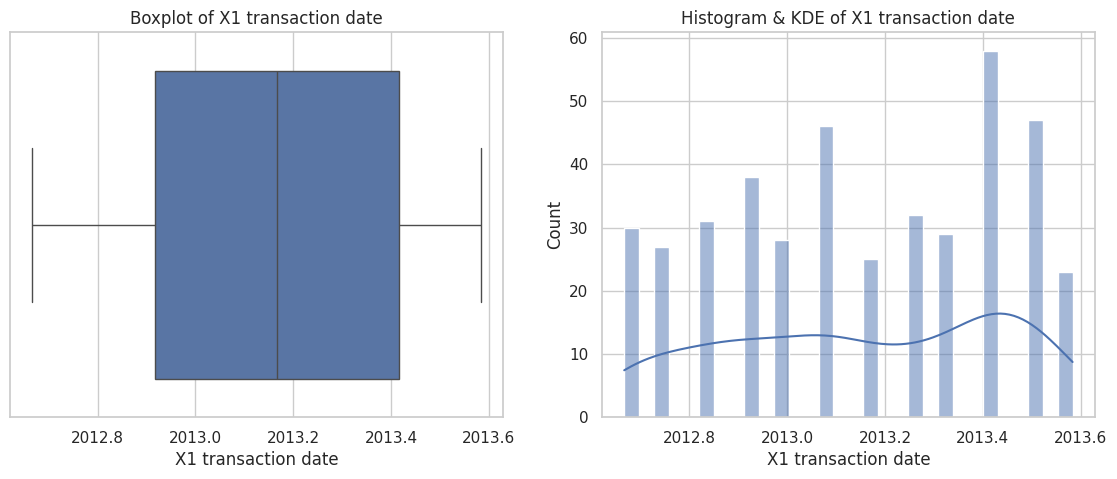

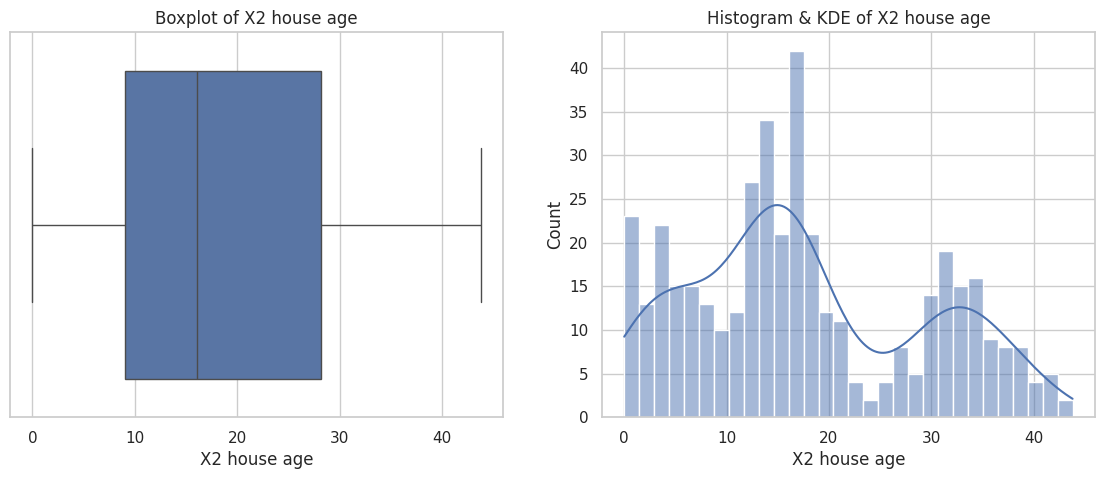

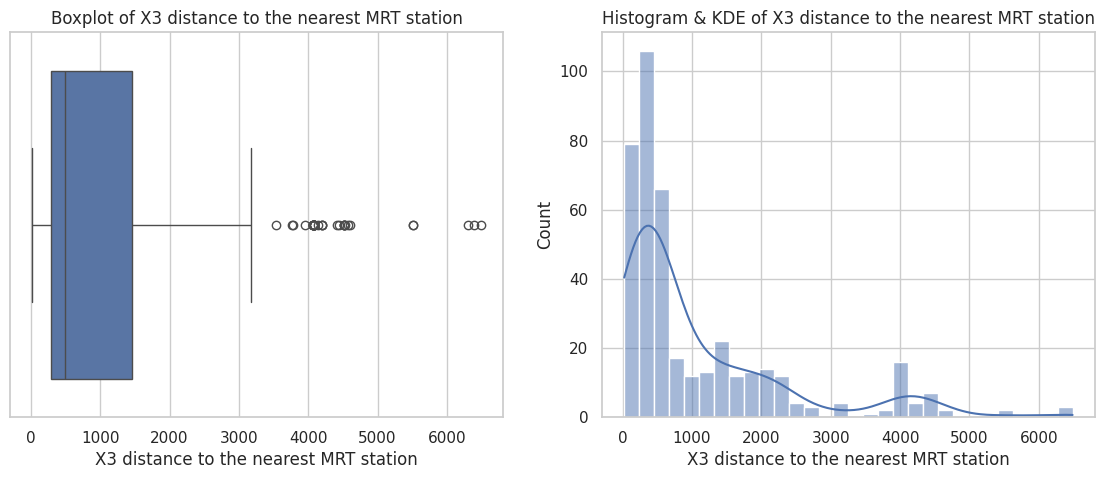

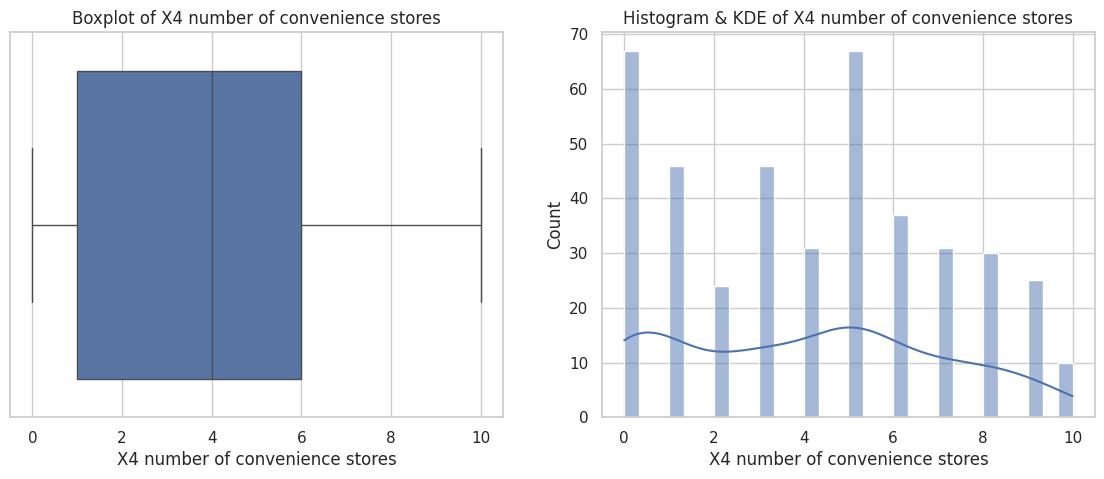

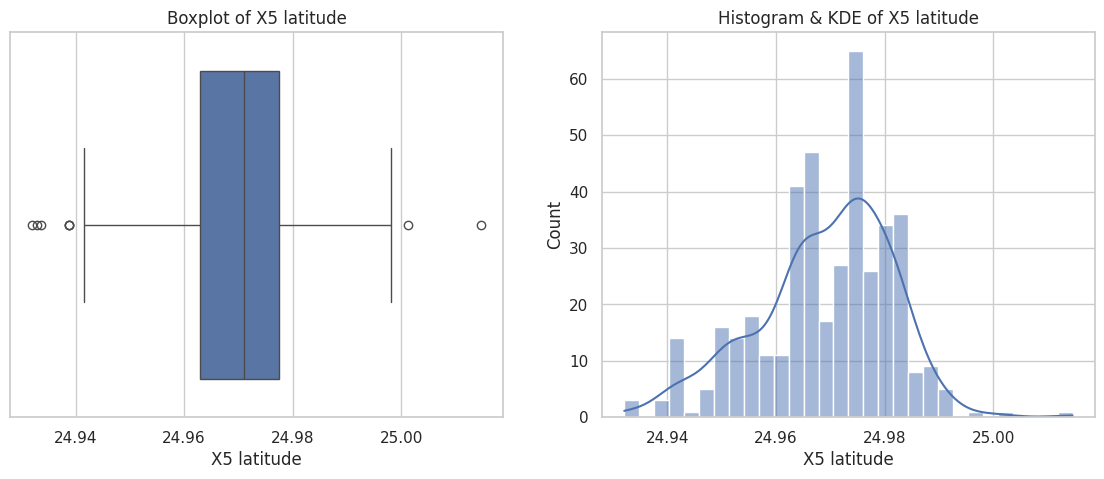

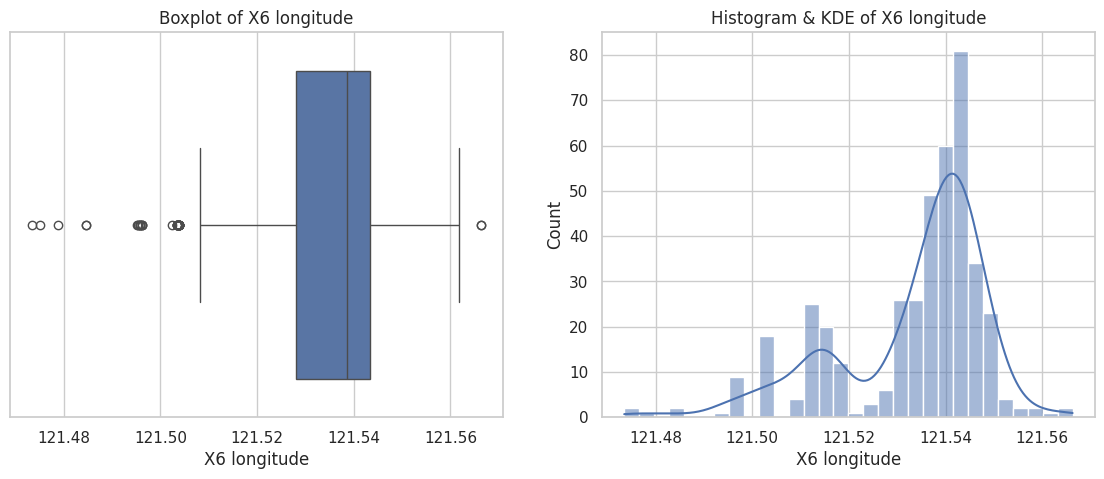

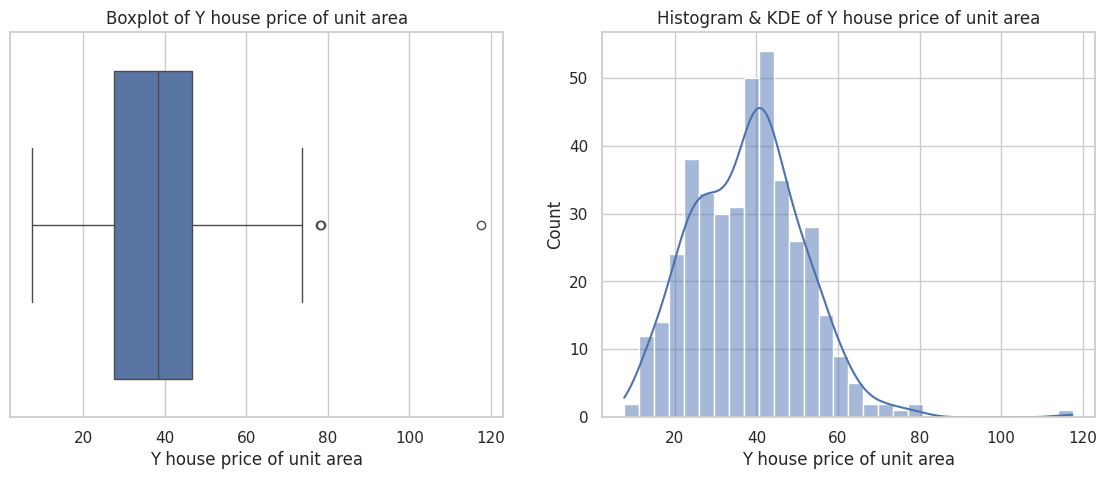

In [5]:
#checking for outliers

sns.set(style="whitegrid")

# Plot boxplots and bell curves for each numerical feature
for col in numerical_data.columns:
    plt.figure(figsize=(14, 5))

    # Boxplot (shows outliers as points beyond whiskers)
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    # Bell curve: histogram + KDE (to check distribution shape)
    plt.subplot(1, 2, 2)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram & KDE of {col}')

    plt.show()

In [6]:
#performing EDA

from collections import OrderedDict
stats=[]
for i in numerical_data:
    numerical_stats=OrderedDict({
        'feature':i,
        'mean':df[i].mean(),
        'median':df[i].median(),
        'mode':df[i].mode()[0],
        'std':df[i].std(),
        'min':df[i].min(),
        'max':df[i].max(),
        'skewness':df[i].skew(),
        'kurtosis':df[i].kurt()
    })
    stats.append(numerical_stats)
    report=pd.DataFrame(stats)


# Outlier Identification :
outlier_label = []
for col in report['feature']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LW = Q1 - 1.5 * IQR   # LW : Lower Whisker Line
    UW = Q3 + 1.5 * IQR   # UW : Upper Whisker Line
    outliers = df[(df[col] < LW) | (df[col] > UW)]
    if not outliers.empty:
        outlier_label.append("Has Outliers")
    else:
        outlier_label.append("No Outliers")

report["Outlier Comment"] = outlier_label

# Checking Report
report

,feature,mean,median,mode,std,min,max,skewness,kurtosis,Outlier Comment
0,No,207.500000,207.500000,1.000000,119.655756,1.000000,414.000000,0.000000,-1.200000,No Outliers
1,X1 transaction date,2013.148953,2013.166667,2013.416667,0.281995,2012.666667,2013.583333,-0.150834,-1.231946,No Outliers
2,X2 house age,17.712560,16.100000,0.000000,11.392485,0.000000,43.800000,0.382926,-0.877120,No Outliers
3,X3 distance to the nearest MRT station,1083.885689,492.231300,289.324800,1262.109595,23.382840,6488.021000,1.888757,3.207868,Has Outliers
4,X4 number of convenience stores,4.094203,4.000000,0.000000,2.945562,0.000000,10.000000,0.154607,-1.065751,No Outliers
5,X5 latitude,24.969030,24.971100,24.974330,0.012410,24.932070,25.014590,-0.438598,0.269070,Has Outliers
6,X6 longitude,121.533361,121.538630,121.543480,0.015347,121.473530,121.566270,-1.219591,1.201792,Has Outliers
7,Y house price of unit area,37.980193,38.450000,24.700000,13.606488,7.600000,117.500000,0.599853,2.179097,Has Outliers


In [7]:
df.isnull().sum()

,0
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


In [8]:
#using labelencoder to encode all the categorical data
#using labelencoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    combined[col] = le.fit_transform(combined[col])

In [9]:
#train test split
X=df.drop('Y house price of unit area',axis=1)
y=df['Y house price of unit area']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)


In [10]:
#the dataset has minor outliers
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train



array([[0.15012107, 0.27272729, 0.39269406, ..., 0.3       , 0.31925007,
        0.42063834],
       [0.33656174, 0.        , 0.29452055, ..., 0.5       , 0.34724056,
        0.68837611],
       [0.39951574, 0.27272729, 0.31278539, ..., 0.1       , 0.50290467,
        0.86672418],
       ...,
       [0.06053269, 0.45454541, 0.66894977, ..., 0.2       , 0.48283602,
        0.47153332],
       [0.47457627, 0.36363635, 0.52054795, ..., 0.2       , 0.55650911,
        0.79361656],
       [0.42372881, 0.45454541, 0.68949772, ..., 0.3       , 0.41193557,
        0.6906405 ]])

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Build the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression (linear activation by default)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Set early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict on test data
y_pred_nn = model.predict(X_test).flatten()

# Evaluate the model
r2_nn = r2_score(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)

model.summary()

print(f"\n📊 Neural Network Performance:")
print(f"R² Score     : {r2_nn:.4f}")
print(f"MAE          : {mae_nn:.4f}")
print(f"MSE          : {mse_nn:.4f}")
print(f"RMSE         : {mse_nn ** 0.5:.4f}")

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 1606.6285 - mae: 37.1038 - val_loss: 1561.4373 - val_mae: 37.8538
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1583.5476 - mae: 36.9196 - val_loss: 1540.4384 - val_mae: 37.5803
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1668.0522 - mae: 37.3927 - val_loss: 1517.5338 - val_mae: 37.2786
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1717.3654 - mae: 38.0242 - val_loss: 1490.9436 - val_mae: 36.9229
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1631.4670 - mae: 36.8711 - val_loss: 1458.3704 - val_mae: 36.4795
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1630.6395 - mae: 37.1776 - val_loss: 1414.8506 - val_mae: 35.8767
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1421.3615 - mae: 34.9416 - val_loss: 1355.2681 - val_mae: 35.0395
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1355.8755 - mae: 33.7575 - val_loss: 1275.9918 - val_mae: 33.8945
Epoch 9/

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,877 (30.77 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,252 (20.52 KB)


📊 Neural Network Performance:
R² Score     : 0.5505
MAE          : 5.7826
MSE          : 52.3121
RMSE         : 7.2327
